## Language-Conditioned Query Encoder (Phase 2b)

Phase 2a showed that language-aware hard negative mining closes 99.7% of the FLORES hard-pool gap but catastrophically collapses bystander language retrieval: EN→FR/DE/SW P@1 drops to ~1–2% (barely above chance on a 1012-candidate pool). The mechanism is a **global push** — every FR/DE/SW/AR sentence is unconditionally repelled from EN queries during training, so the model generalises this to all EN→FR/DE/SW/AR retrieval.

Phase 2b replaces the global push with a **targeted pull**. A learned per-target-language embedding is summed into the *unit-normalised* mean-pooled CLS before the projection head. At inference the query is conditioned on the desired target language, shifting it toward that language's subspace without globally repelling bystanders during training.

**Architecture**
- Base: XLM-R + projection head (768 → 2048 → 256), same as Phase 1/2a
- New: `nn.Embedding(5, 768)` — one 768-dim embedding per target language (ES/FR/DE/SW/AR), initialised at std=0.01
- Query: `project(normalise(normalise(pool(en)) + lang_emb[tgt]))` — mean pool is normalised to unit sphere *before* lang_emb is added, so the embedding contributes ~27% of the combined vector magnitude at initialisation. Normalising after addition is then applied before the projection head.
- Candidates: `project(normalise(pool(sent)))` — unconditioned, same as vanilla

**Why normalise the mean pool first?**
XLM-R mean pools have unnormalised magnitudes of ~8–12. Adding lang_emb (magnitude ~0.28 at std=0.01) to a vector of magnitude ~10 gives only ~2.8% contribution before normalisation — too small for the projection head to use. Normalising to unit norm first ensures lang_emb contributes ~27% of the combined vector, giving the model a meaningful signal to learn from.

**Training**
- **Main loss**: InfoNCE on OPUS-100 EN–ES pairs, EN query conditioned with ES embedding
- **Auxiliary loss**: 6-tuple contrastive loss on FLORES dev — for each of the 5 target languages, conditions the EN query and pulls toward the target translation while pushing away same-sentence translations in all other languages. FR/DE negatives weighted 2×.
- **Sweep**: `lambda_aux` ∈ {0.1, 0.5, 1.0, 2.0}

**Key success criteria**
1. P@1-target on FLORES hard pool approaches hard-neg 2K (0.991) — gap closed
2. EN→FR/DE/SW/AR easy-pool P@1 stays high when queries are conditioned on those languages — no bystander collapse

In [2]:
!pip install -q transformers datasets torch

import os
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import (XLMRobertaModel, XLMRobertaTokenizerFast,
                          get_linear_schedule_with_warmup)
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MAX_STEPS        = 2000
BATCH_SIZE       = 32
LR               = 2e-5
TEMPERATURE      = 0.07
WARMUP_STEPS     = 200
LOG_EVERY        = 200
CHECKPOINT_STEPS = [500, 1000, 1500, 2000]

LAMBDA_AUX_SWEEP = [0.1, 0.5, 1.0, 2.0]

# FR/DE weighted 2x in cross-language hard negatives (matches observed error distribution)
CROSS_WEIGHTS = {'es': 1.0, 'fr': 2.0, 'de': 2.0, 'sw': 1.0, 'ar': 1.0}

LANG_ORDER  = ['es', 'fr', 'de', 'sw', 'ar']
LANG_TO_IDX = {l: i for i, l in enumerate(LANG_ORDER)}
NUM_LANGS   = len(LANG_ORDER)
LANG_CODES  = {
    'es': 'spa_Latn', 'fr': 'fra_Latn', 'de': 'deu_Latn',
    'sw': 'swh_Latn', 'ar': 'arb_Arab',
}

# Phase 1 / Phase 2a baselines for comparison
VANILLA_2K  = {'easy': 0.9941, 'target': 0.3824, 'any': 1.0000, 'gap': 0.6117}
HARD_NEG_2K = {'easy': 0.9930, 'target': 0.9911, 'any': 0.9930, 'gap': 0.0019}
HN_BYSTANDER = {'es': 0.9951, 'fr': 0.0198, 'de': 0.0128, 'sw': 0.0158, 'ar': 0.1551}

tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')
print('Setup complete.')

Device: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setup complete.


In [3]:
from huggingface_hub import notebook_login
notebook_login()

## Model

In [4]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=2048, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, output_dim))
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class LanguageConditionedWrapper(nn.Module):
    """
    XLM-R with a learned per-target-language embedding summed into the
    unit-normalised mean-pooled CLS before the projection head.

    The mean pool is normalised to unit norm BEFORE adding lang_emb so the
    embedding has a meaningful contribution (~27% at std=0.01 initialisation)
    rather than being swamped by the unnormalised mean pool magnitude (~8-12).
    This is also consistent with Phase 1/2a where the projection head always
    received a normalised input.

    Queries are conditioned on the desired target language at inference time.
    Candidates are encoded without conditioning (identical to vanilla InfoNCE).
    """
    def __init__(self, model_name='xlm-roberta-base'):
        super().__init__()
        self.model      = XLMRobertaModel.from_pretrained(model_name)
        self.projection = ProjectionHead(768, 2048, 256)
        self.lang_emb   = nn.Embedding(NUM_LANGS, 768)
        nn.init.normal_(self.lang_emb.weight, std=0.01)

    def _mean_pool_unnorm(self, hidden, mask):
        """Unnormalized mean pool. Internal use only."""
        m = mask.unsqueeze(-1).float()
        return (hidden * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def encode_base(self, input_ids, attention_mask):
        """Unit-normalised 768-dim mean pool, no lang conditioning, no projection."""
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return F.normalize(
            self._mean_pool_unnorm(out.last_hidden_state, attention_mask), dim=-1
        )

    def forward(self, input_ids, attention_mask, lang=None):
        """
        Project to 256-dim.
        lang: target language string e.g. 'es', or None for unconditioned candidates.
        """
        base = self.encode_base(input_ids, attention_mask)  # (B, 768) unit norm
        if lang is not None:
            idx  = torch.tensor(LANG_TO_IDX[lang], device=input_ids.device)
            base = base + self.lang_emb(idx)                # add lang offset, then re-normalise
        return self.projection(F.normalize(base, dim=-1))

    def encode(self, input_ids, attention_mask, lang=None):
        """768-dim encoder output (no projection). Used for eval."""
        base = self.encode_base(input_ids, attention_mask)  # (B, 768) unit norm
        if lang is not None:
            idx  = torch.tensor(LANG_TO_IDX[lang], device=input_ids.device)
            base = base + self.lang_emb(idx)
        return F.normalize(base, dim=-1)


print('Model definition ready.')

Model definition ready.


## Losses

**Main loss**: Standard symmetric InfoNCE on OPUS-100 EN–ES pairs. EN query is conditioned
with the ES language embedding; ES candidate is unconditioned.

**Auxiliary loss** (`aux_lang_cond_loss`): For each of the 5 target languages, the EN query
is conditioned on that language and the contrastive loss is computed with:
- *In-batch positives/negatives*: the B candidates in the target language
- *Per-example cross-language hard negatives*: the same source sentence translated into
  each of the other 4 languages. FR/DE negatives are weighted 2×.

The `en_base` encoding is shared across all 5 target-language conditioning variants
(one encoder pass for EN, five projection passes for the five conditioned queries).
The auxiliary loss returns the mean over all 5 target languages.

In [5]:
def infonce_loss(z_src, z_tgt, tau=TEMPERATURE):
    sim    = z_src @ z_tgt.T / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    return (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2.0


def aux_lang_cond_loss(model, flores_encs, tau=TEMPERATURE):
    """
    Auxiliary 6-tuple contrastive loss on FLORES dev data.

    For each target language tgt in {ES, FR, DE, SW, AR}:
      1. Condition EN query: z_query = project(norm(encode_base(en) + lang_emb[tgt]))
         encode_base already returns unit-norm vectors, so lang_emb has ~27% contribution.
      2. Positive: the in-batch target-language candidates (z_cands[tgt])
      3. Hard negatives: same-sentence translations in all other languages
         (per-example, not in-batch), FR/DE weighted 2x

    Returns mean loss over all 5 target languages.
    """
    # encode_base already returns unit-normalised vectors, so lang_emb additions
    # have a well-calibrated contribution. One EN encoder pass shared across all targets.
    en_base = model.encode_base(
        flores_encs['en']['input_ids'],
        flores_encs['en']['attention_mask']
    )  # (B, 768) unit norm

    # Encode all 5 target language candidates (unconditioned projections)
    z_cands = {
        lang: model.forward(
            flores_encs[lang]['input_ids'],
            flores_encs[lang]['attention_mask'],
            lang=None
        )
        for lang in LANG_ORDER
    }  # each (B, 256)

    total_loss = 0.0
    for tgt in LANG_ORDER:
        # Conditioned query: add lang_emb offset to unit-norm base, re-normalise, project
        lang_idx = torch.tensor(LANG_TO_IDX[tgt], device=DEVICE)
        z_query  = model.projection(
            F.normalize(en_base + model.lang_emb(lang_idx), dim=-1)
        )  # (B, 256)

        # Positive score (diagonal: query i vs candidate i)
        pos = (z_query * z_cands[tgt]).sum(-1) / tau  # (B,)

        # Denominator: in-batch target candidates
        all_scores = z_query @ z_cands[tgt].T / tau   # (B, B)

        # Per-example cross-language hard negatives
        for other in LANG_ORDER:
            if other == tgt:
                continue
            w    = CROSS_WEIGHTS[other]
            hard = (z_query * z_cands[other]).sum(-1, keepdim=True) / tau  # (B, 1)
            if w != 1.0:
                hard = hard + math.log(w)
            all_scores = torch.cat([all_scores, hard], dim=1)

        loss_tgt   = -(pos - torch.logsumexp(all_scores, dim=1)).mean()
        total_loss += loss_tgt

    return total_loss / NUM_LANGS


print('Loss functions ready.')

Loss functions ready.


## Utilities and Data

In [6]:
def collate_pairs(pairs, max_length=128):
    src = tokenizer([p[0] for p in pairs], padding=True, truncation=True,
                    max_length=max_length, return_tensors='pt')
    tgt = tokenizer([p[1] for p in pairs], padding=True, truncation=True,
                    max_length=max_length, return_tensors='pt')
    return src, tgt


def collate_sixtuples(batch, max_length=128):
    """Tokenise a list of {lang: text} dicts into {lang: tensor_dict}."""
    return {
        lang: tokenizer(
            [row[lang] for row in batch], padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        )
        for lang in ['en'] + LANG_ORDER
    }


def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        yield ex['translation'][src_lang], ex['translation'][tgt_lang]


def flores_dev_stream(dev_en, dev_sents, batch_size=32, seed=0):
    rng     = random.Random(seed)
    indices = list(range(len(dev_en)))
    while True:
        rng.shuffle(indices)
        buf = []
        for i in indices:
            buf.append({
                lang: (dev_en if lang == 'en' else dev_sents[lang])[i]
                for lang in ['en'] + LANG_ORDER
            })
            if len(buf) == batch_size:
                yield buf
                buf = []


print('Utilities ready.')

Utilities ready.


In [7]:
def load_flores(lang_code, split='devtest'):
    ds = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [ex['text'] for ex in ds]

print('Loading FLORES dev (auxiliary training signal)...')
dev_en    = load_flores('eng_Latn', split='dev')
dev_sents = {lang: load_flores(code, split='dev') for lang, code in LANG_CODES.items()}
print(f'  {len(dev_en)} sentences per language')

print('Loading FLORES devtest (evaluation)...')
en_sents   = load_flores('eng_Latn', split='devtest')
lang_sents = {lang: load_flores(code, split='devtest') for lang, code in LANG_CODES.items()}
N = len(en_sents)
print(f'  {N} sentences per language  |  hard pool = {N * NUM_LANGS}')

Loading FLORES dev (auxiliary training signal)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

  1012 sentences per language  |  hard pool = 5060


## Evaluation

`evaluate(model, target_lang='es')` runs the standard hard-pool eval with EN queries
conditioned on `target_lang`. For the main experiment this is always `'es'`.

`bystander_eval(model)` is the key differentiator from Phase 2a: for each language, it
conditions EN queries on that language and measures easy-pool P@1. Hard neg mining
collapsed FR/DE/SW to ~1–2% here. Phase 2b should maintain high P@1 for all languages
because the conditioning is a targeted pull at inference time, not a training-time push.

In [8]:
@torch.no_grad()
def _encode_all(mdl, target_lang):
    """Encode FLORES devtest. EN conditioned on target_lang; candidates unconditioned."""
    def enc(sents, lang=None):
        out = []
        for i in range(0, len(sents), 256):
            tok = {k: v.to(DEVICE) for k, v in tokenizer(
                sents[i:i+256], padding=True, truncation=True,
                max_length=128, return_tensors='pt').items()}
            out.append(mdl.encode(tok['input_ids'], tok['attention_mask'], lang=lang).cpu())
        return torch.cat(out, 0)

    en    = enc(en_sents, lang=target_lang)
    langs = {lang: enc(lang_sents[lang], lang=None) for lang in LANG_ORDER}
    return en, langs


def evaluate(mdl, target_lang='es'):
    """Hard-pool P@1 with EN queries conditioned on target_lang."""
    mdl.eval()
    en_embs, lang_embs = _encode_all(mdl, target_lang)

    p1_easy   = float((en_embs @ lang_embs['es'].T).argmax(1).eq(
                    torch.arange(N)).float().mean())
    hard_pool = torch.cat([lang_embs[l] for l in LANG_ORDER], dim=0)
    top1      = (en_embs @ hard_pool.T).argmax(dim=1)
    p1_target = float(top1.eq(torch.arange(N)).float().mean())
    p1_any    = float((top1 % N).eq(torch.arange(N)).float().mean())

    return p1_easy, p1_target, p1_any


def bystander_eval(mdl):
    """
    For each language, condition EN queries on that language and measure easy-pool P@1.
    Tests whether conditioning generalises: 'fr' conditioning should retrieve French,
    'de' should retrieve German, etc.
    """
    mdl.eval()
    results = {}
    for lang in LANG_ORDER:
        en_embs, lang_embs = _encode_all(mdl, lang)
        top1 = (en_embs @ lang_embs[lang].T).argmax(dim=1)
        results[lang] = float(top1.eq(torch.arange(N)).float().mean())
    return results


print('Eval functions ready.')

Eval functions ready.


## Training

Each step draws one OPUS-100 EN–ES batch (main InfoNCE, EN query conditioned on ES)
and one FLORES dev 6-tuple batch (auxiliary loss, all 5 target languages).
Total loss = `loss_main + lambda_aux * loss_aux`.

The sweep runs `lambda_aux` ∈ {0.1, 0.5, 1.0, 2.0} sequentially, skipping any run
where all four checkpoints already exist on disk.

In [9]:
def train_phase2b(lambda_aux):
    """Train language-conditioned encoder for given lambda_aux. Loads if checkpoints exist."""
    prefix    = f'lang_cond_l{lambda_aux}'
    all_exist = all(
        os.path.exists(f'{prefix}_{s}steps_enes.pt') for s in CHECKPOINT_STEPS
    )
    curve = []

    if all_exist:
        print(f'lambda_aux={lambda_aux}: all checkpoints found, loading...')
        for s in CHECKPOINT_STEPS:
            ckpt  = torch.load(f'{prefix}_{s}steps_enes.pt', map_location=DEVICE)
            model = LanguageConditionedWrapper().to(DEVICE)
            model.load_state_dict(ckpt['model_state_dict'])
            p1_easy, p1_target, p1_any = evaluate(model)
            curve.append((s, p1_easy, p1_target, p1_any))
            print(f'  step {s:>4}: easy={p1_easy:.4f}  target={p1_target:.4f}  '
                  f'any={p1_any:.4f}')
            del model; torch.cuda.empty_cache()
        return curve

    print(f'\nTraining Phase 2b  lambda_aux={lambda_aux}...')
    model     = LanguageConditionedWrapper().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(optimizer, WARMUP_STEPS, MAX_STEPS)

    model.train()
    opus_iter   = opus_stream('en-es', seed=42)
    flores_iter = flores_dev_stream(dev_en, dev_sents, batch_size=BATCH_SIZE, seed=0)
    opus_buf, step = [], 0
    losses_main, losses_aux = [], []

    for src_text, tgt_text in opus_iter:
        opus_buf.append((src_text, tgt_text))
        if len(opus_buf) < BATCH_SIZE:
            continue

        # Main InfoNCE: EN conditioned on ES -> ES unconditioned
        src_enc, tgt_enc = collate_pairs(opus_buf); opus_buf = []
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}
        z_src     = model.forward(src_enc['input_ids'], src_enc['attention_mask'], lang='es')
        z_tgt     = model.forward(tgt_enc['input_ids'], tgt_enc['attention_mask'], lang=None)
        loss_main = infonce_loss(z_src, z_tgt)

        # Auxiliary 6-tuple loss on FLORES dev
        flores_batch = next(flores_iter)
        flores_encs  = {
            lang: {k: v.to(DEVICE) for k, v in enc.items()}
            for lang, enc in collate_sixtuples(flores_batch).items()
        }
        loss_aux_val = aux_lang_cond_loss(model, flores_encs)

        loss = loss_main + lambda_aux * loss_aux_val
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        step += 1
        losses_main.append(loss_main.item())
        losses_aux.append(loss_aux_val.item())

        if step % LOG_EVERY == 0:
            avg_main = sum(losses_main[-LOG_EVERY:]) / LOG_EVERY
            avg_aux  = sum(losses_aux[-LOG_EVERY:])  / LOG_EVERY
            print(f'  step {step:>4}/{MAX_STEPS}  main={avg_main:.4f}  aux={avg_aux:.4f}')

        if step in CHECKPOINT_STEPS:
            p1_easy, p1_target, p1_any = evaluate(model)
            curve.append((step, p1_easy, p1_target, p1_any))
            path = f'{prefix}_{step}steps_enes.pt'
            torch.save({'model_state_dict': model.state_dict(),
                        'step': step, 'lambda_aux': lambda_aux}, path)
            print(f'  ckpt {step:>4}: easy={p1_easy:.4f}  target={p1_target:.4f}  '
                  f'any={p1_any:.4f}  saved {path}  ({os.path.getsize(path)/1e6:.0f}\u00a0MB)')
            model.train()

        if step >= MAX_STEPS:
            break

    del optimizer, scheduler
    print(f'Done  lambda_aux={lambda_aux}.')
    return curve


print('Training function ready.')

Training function ready.


In [10]:
all_curves = {}
for lam in LAMBDA_AUX_SWEEP:
    all_curves[lam] = train_phase2b(lam)
print('\nAll runs complete.')


Training Phase 2b  lambda_aux=0.1...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  step  200/2000  main=2.0769  aux=2.1782
  step  400/2000  main=0.3208  aux=0.1201
  ckpt  500: easy=0.9842  target=0.8498  any=0.9960  saved lang_cond_l1.0_500steps_enes.pt  (1121 MB)
  step  600/2000  main=0.2584  aux=0.0798
  step  800/2000  main=0.2259  aux=0.0667
  step 1000/2000  main=0.2199  aux=0.0589
  ckpt 1000: easy=0.9951  target=0.9565  any=0.9970  saved lang_cond_l1.0_1000steps_enes.pt  (1121 MB)
  step 1200/2000  main=0.1913  aux=0.0535
  step 1400/2000  main=0.1962  aux=0.0503
  ckpt 1500: easy=0.9901  target=0.9486  any=0.9951  saved lang_cond_l1.0_1500steps_enes.pt  (1121 MB)
  step 1600/2000  main=0.1924  aux=0.0463
  step 1800/2000  main=0.1910  aux=0.0452
  step 2000/2000  main=0.2070  aux=0.0435
  ckpt 2000: easy=0.9921  target=0.9585  any=0.9980  saved lang_cond_l1.0_2000steps_enes.pt  (1121 MB)
Done  lambda_aux=1.0.

Training Phase 2b  lambda_aux=2.0...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  step  200/2000  main=1.9131  aux=1.8910
  step  400/2000  main=0.3066  aux=0.0911
  ckpt  500: easy=0.9941  target=0.8883  any=0.9960  saved lang_cond_l2.0_500steps_enes.pt  (1121 MB)
  step  600/2000  main=0.2533  aux=0.0621
  step  800/2000  main=0.2243  aux=0.0531
  step 1000/2000  main=0.2159  aux=0.0474
  ckpt 1000: easy=0.9911  target=0.9308  any=0.9960  saved lang_cond_l2.0_1000steps_enes.pt  (1121 MB)
  step 1200/2000  main=0.1921  aux=0.0428
  step 1400/2000  main=0.1943  aux=0.0404
  ckpt 1500: easy=0.9931  target=0.9318  any=0.9980  saved lang_cond_l2.0_1500steps_enes.pt  (1121 MB)
  step 1600/2000  main=0.1956  aux=0.0378
  step 1800/2000  main=0.1948  aux=0.0369
  step 2000/2000  main=0.2038  aux=0.0354
  ckpt 2000: easy=0.9931  target=0.9447  any=0.9980  saved lang_cond_l2.0_2000steps_enes.pt  (1121 MB)
Done  lambda_aux=2.0.

All runs complete.


## Results

Key questions:
1. Does any `lambda_aux` value close the FLORES gap (P@1-target approaching 0.991)?
2. Which `lambda_aux` gives the best P@1-target at 2K steps?
3. Does P@1-any stay near 1.000, or does conditioning introduce genuine retrieval errors?

In [11]:
gap_vanilla = VANILLA_2K['gap']

print('=== Hard Pool P@1 at 2K Steps ===\n')
print(f'{"Model":<32}  {"P@1-easy":>9}  {"P@1-target":>11}  {"P@1-any":>9}  '
      f'{"Gap":>8}  {"% closed":>9}')
print('-' * 86)

print(f'{"Vanilla InfoNCE 2K":<32}  {VANILLA_2K["easy"]:>9.4f}  '
      f'{VANILLA_2K["target"]:>11.4f}  {VANILLA_2K["any"]:>9.4f}  '
      f'{VANILLA_2K["gap"]:>8.4f}  {"0.0%":>9}')
print(f'{"Hard neg mining 2K":<32}  {HARD_NEG_2K["easy"]:>9.4f}  '
      f'{HARD_NEG_2K["target"]:>11.4f}  {HARD_NEG_2K["any"]:>9.4f}  '
      f'{HARD_NEG_2K["gap"]:>8.4f}  {"99.7%":>9}')
print()

best_lam, best_target = None, 0.0
for lam in LAMBDA_AUX_SWEEP:
    if not all_curves.get(lam):
        continue
    row = next((r for r in all_curves[lam] if r[0] == 2000), all_curves[lam][-1])
    _, e, t, a = row
    gap    = e - t
    closed = (gap_vanilla - gap) / gap_vanilla * 100
    label  = f'Phase 2b  lambda={lam}'
    print(f'{label:<32}  {e:>9.4f}  {t:>11.4f}  {a:>9.4f}  '
          f'{gap:>8.4f}  {closed:>8.1f}%')
    if t > best_target:
        best_target, best_lam = t, lam

print(f'\nBest lambda_aux = {best_lam}  (P@1-target = {best_target:.4f})')

=== Hard Pool P@1 at 2K Steps ===

Model                              P@1-easy   P@1-target    P@1-any       Gap   % closed
--------------------------------------------------------------------------------------
Vanilla InfoNCE 2K                   0.9941       0.3824     1.0000    0.6117       0.0%
Hard neg mining 2K                   0.9930       0.9911     0.9930    0.0019      99.7%

Phase 2b  lambda=0.1                 0.9862       0.9358     0.9921    0.0504      91.8%
Phase 2b  lambda=0.5                 0.9951       0.9802     0.9980    0.0148      97.6%
Phase 2b  lambda=1.0                 0.9921       0.9585     0.9980    0.0336      94.5%
Phase 2b  lambda=2.0                 0.9931       0.9447     0.9980    0.0484      92.1%

Best lambda_aux = 0.5  (P@1-target = 0.9802)


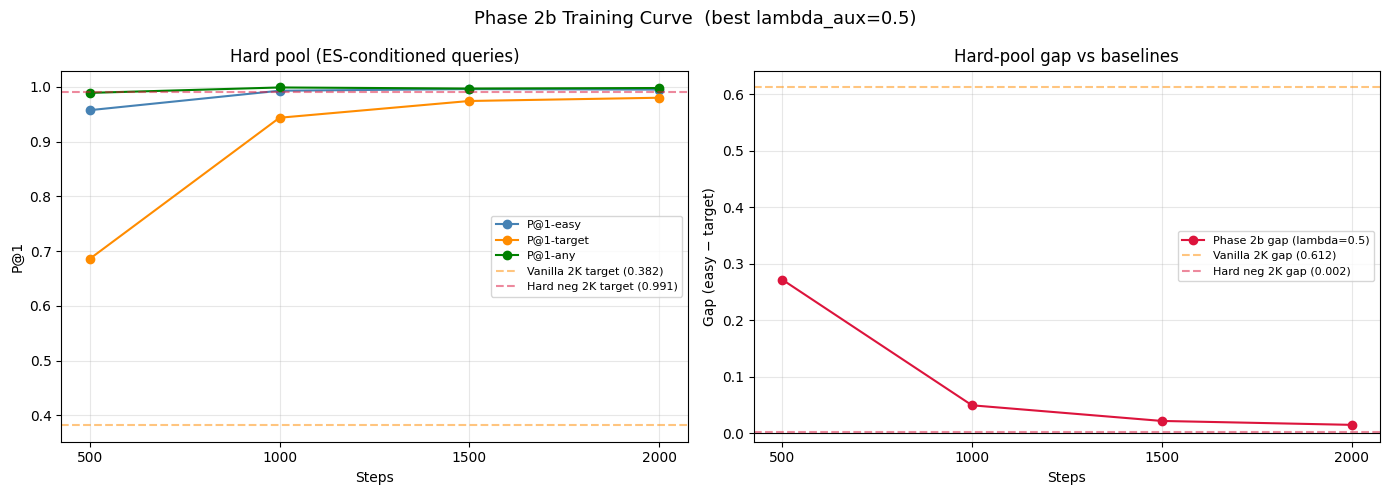

In [12]:
if best_lam is not None and all_curves.get(best_lam):
    curve   = all_curves[best_lam]
    steps_  = [r[0] for r in curve]
    easy_   = [r[1] for r in curve]
    target_ = [r[2] for r in curve]
    any_    = [r[3] for r in curve]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Phase 2b Training Curve  (best lambda_aux={best_lam})', fontsize=13)

    ax = axes[0]
    ax.plot(steps_, easy_,   'o-', color='steelblue',  label='P@1-easy')
    ax.plot(steps_, target_, 'o-', color='darkorange', label='P@1-target')
    ax.plot(steps_, any_,    'o-', color='green',      label='P@1-any')
    ax.axhline(VANILLA_2K['target'],  color='darkorange', linestyle='--', alpha=0.5,
               label=f'Vanilla 2K target ({VANILLA_2K["target"]:.3f})')
    ax.axhline(HARD_NEG_2K['target'], color='crimson',    linestyle='--', alpha=0.5,
               label=f'Hard neg 2K target ({HARD_NEG_2K["target"]:.3f})')
    ax.set_xlabel('Steps'); ax.set_ylabel('P@1')
    ax.set_title('Hard pool (ES-conditioned queries)')
    ax.set_xticks(steps_); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    gaps = [e - t for e, t in zip(easy_, target_)]
    ax.plot(steps_, gaps, 'o-', color='crimson',
            label=f'Phase 2b gap (lambda={best_lam})')
    ax.axhline(VANILLA_2K['gap'],   color='darkorange', linestyle='--', alpha=0.5,
               label=f'Vanilla 2K gap ({VANILLA_2K["gap"]:.3f})')
    ax.axhline(HARD_NEG_2K['gap'], color='crimson',    linestyle='--', alpha=0.5,
               label=f'Hard neg 2K gap ({HARD_NEG_2K["gap"]:.3f})')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Steps'); ax.set_ylabel('Gap (easy \u2212 target)')
    ax.set_title('Hard-pool gap vs baselines')
    ax.set_xticks(steps_); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase2b_training_curve.png', dpi=150)
    plt.show()

## Bystander Language Eval

The central test for Phase 2b. Hard neg mining collapsed EN→FR/DE/SW P@1 to ~1–2%
because it pushed those languages away globally during training. Phase 2b should avoid
this: the language embedding is a targeted pull at inference time, so conditioning EN
queries on 'fr' should still retrieve French documents correctly.

Expected outcome if Phase 2b works: all five languages at high easy-pool P@1
when conditioned on their respective embeddings.

In [13]:
if best_lam is None:
    print('No trained checkpoints found. Run training cells first.')
else:
    ckpt_path = f'lang_cond_l{best_lam}_2000steps_enes.pt'
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model = LanguageConditionedWrapper().to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded {ckpt_path}')

    bs_results = bystander_eval(model)
    del model; torch.cuda.empty_cache()

    print(f'\n=== Bystander Easy-Pool Eval (EN\u2192{{lang}} P@1, queries conditioned on target lang) ===')
    print(f'Hard neg 2K shown for comparison \u2014 those numbers represent catastrophic collapse.\n')
    print(f'{"Lang":<6}  {"Phase 2b (best \u03bb)":>18}  {"Hard Neg 2K":>12}  {"\u0394 vs hard neg":>14}')
    print('-' * 56)
    for lang in LANG_ORDER:
        p2b = bs_results[lang]
        hn  = HN_BYSTANDER[lang]
        print(f'{lang.upper():<6}  {p2b:>18.4f}  {hn:>12.4f}  {p2b - hn:>+14.4f}')

    print('\n=== Interpretation ===')
    fr_ok = bs_results.get('fr', 0) > 0.80
    de_ok = bs_results.get('de', 0) > 0.80
    sw_ok = bs_results.get('sw', 0) > 0.80
    if fr_ok and de_ok and sw_ok:
        print('  Phase 2b maintains bystander retrieval across all languages.')
        print('  Targeted pull avoids global push collapse. This is a general multilingual fix.')
    elif bs_results.get('fr', 0) > 0.40:
        print('  Partial bystander recovery vs hard neg. Some degradation remains.')
        print('  Consider: higher lambda_aux, or increase lang_emb std to 0.05-0.1 for stronger signal.')
    else:
        print('  Bystander collapse persists. Suggested fixes:')
        print('  - Increase lang_emb std from 0.01 to 0.05-0.1 (bolder initialisation)')
        print('  - Verify lang= parameter is passed at eval time')
        print('  - Consider separate query/candidate projection heads')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded lang_cond_l0.5_2000steps_enes.pt

=== Bystander Easy-Pool Eval (EN→{lang} P@1, queries conditioned on target lang) ===
Hard neg 2K shown for comparison — those numbers represent catastrophic collapse.

Lang     Phase 2b (best λ)   Hard Neg 2K   Δ vs hard neg
--------------------------------------------------------
ES                  0.9951        0.9951         -0.0000
FR                  0.9960        0.0198         +0.9762
DE                  0.9990        0.0128         +0.9862
SW                  0.9476        0.0158         +0.9318
AR                  0.9733        0.1551         +0.8182

=== Interpretation ===
  Phase 2b maintains bystander retrieval across all languages.
  Targeted pull avoids global push collapse. This is a general multilingual fix.


In [17]:
# Bystander eval across all lambda values for the paper's lambda sweep table
print('=== Bystander P@1 Across Lambda Sweep ===\n')
header = f'{"":<6}' + ''.join(f'  {"lambda="+str(lam):>12}' for lam in LAMBDA_AUX_SWEEP)
print(header)
print('-' * len(header))

sweep_bystander = {}
for lam in LAMBDA_AUX_SWEEP:
    path = f'lang_cond_l{lam}_2000steps_enes.pt'
    if not os.path.exists(path):
        sweep_bystander[lam] = None
        continue
    ckpt  = torch.load(path, map_location=DEVICE)
    model = LanguageConditionedWrapper().to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    sweep_bystander[lam] = bystander_eval(model)
    del model; torch.cuda.empty_cache()

for lang in LANG_ORDER:
    row = f'{lang.upper():<6}'
    for lam in LAMBDA_AUX_SWEEP:
        val = sweep_bystander.get(lam)
        row += f'  {val[lang]:>12.4f}' if val else f'  {"n/a":>12}'
    print(row)

=== Bystander P@1 Across Lambda Sweep ===

          lambda=0.1    lambda=0.5    lambda=1.0    lambda=2.0
--------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ES            0.9862        0.9951        0.9921        0.9931
FR            0.9713        0.9960        0.9951        0.9970
DE            0.9812        0.9990        0.9990        0.9980
SW            0.9209        0.9476        0.9536        0.9536
AR            0.9605        0.9733        0.9812        0.9763


In [15]:
from google.colab import files
for lam in LAMBDA_AUX_SWEEP:
    path = f'lang_cond_l{lam}_2000steps_enes.pt'
    if os.path.exists(path):
        files.download(path)
        print(f'Downloading {path}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>